# Contrast Response Demo: Gratings, across NDFs (Alejandro)

Focused subset of `3_contrast_grating_demo.ipynb` for CRF-across-NDFs analysis only -- for
single-NDF CRF plots, Naka-Rushton fits, rasters, or PSTHs, use that notebook instead.

**What this notebook adds on top of the CRF-across-NDFs plots:**
- Exports the exact points each plot draws (population mean/SEM per NDF, per cell type, per
  contrast) to a dataframe/CSV, for analysis outside this notebook.
- Averages the CRF across multiple experiments instead of just one, pooling every matching
  cell from every experiment into one curve per NDF per cell type.


In [1]:
import retinanalysis as ra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


C:\Users\Yasmine Tani\anaconda3\envs\retinanalysis\Lib\site-packages\datajoint\settings.py:992: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


## Find contrast-response datasets

Broad substring search (`'contrast'`), same as the main contrast demo.

In [2]:
contrast_search = ra.get_datasets_from_protocol_names('contrast')
print(contrast_search['protocol_name'].unique())
ra.scrollable_dataframe(contrast_search)


[2026-08-13 19:13:00] DataJoint 2.2.2 connected to root@127.0.0.1:3306

Found 3 protocols matching "contrast":
['manookinlab.protocols.ContrastResponseFlash'
 'manookinlab.protocols.ContrastResponseGrating'
 'manookinlab.protocols.ContrastResponseSpot']

Found 24 experiments, 204 epoch blocks.

<StringArray>
[   'manookinlab.protocols.ContrastResponseSpot',
   'manookinlab.protocols.ContrastResponseFlash',
 'manookinlab.protocols.ContrastResponseGrating']
Length: 3, dtype: str


,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20250912A,data009,3.0,data009,manookinlab.protocols.ContrastResponseSpot,1,20250912A\data009,Control,395,6,1419,4148,3753
1,20250918A,data004,5.0,data004,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data004,Control,396,6,1420,4153,3758
2,20250918A,data008,4.0,data008,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data008,Control,396,6,1420,4157,3762
3,20250918A,data012,3.0,data012,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data012,Control,396,6,1420,4161,3766
4,20250918A,data016,2.0,data016,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data016,Control,396,6,1420,4165,3770
5,20250918A,data020,1.0,data020,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data020,Control,396,6,1420,4169,3774
6,20250918A,data021,0.0,data021,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data021,Control,396,6,1420,4170,3775
7,20250918A,data001,5.0,data001,manookinlab.protocols.ContrastResponseFlash,1,20250918A\data001,Control,396,7,1420,4150,3755
8,20250918A,data002,5.0,data002,manookinlab.protocols.ContrastResponseFlash,1,20250918A\data002,Control,396,7,1420,4151,3756
9,20250918A,data007,4.0,data007,manookinlab.protocols.ContrastResponseFlash,1,20250918A\data007,Control,396,7,1420,4156,3761


## Choose an experiment

`exp_name` is used by the single-experiment CRF-across-NDFs section below. The
multi-experiment averaging section further down uses its own list of experiments and finds
each one's classified chunk independently -- you don't need to change anything here for
that section.

In [4]:
exp_name = '20260529A'

MANUAL_ANALYSIS_CHUNK = None  # e.g. 'chunk13' or 'data001' -- set this to skip auto-detection

analysis_chunk_name = MANUAL_ANALYSIS_CHUNK or ra.find_classified_noise_chunk(exp_name)
if analysis_chunk_name is None:
    print(
        'No classified NDF0/NDF1 white-noise chunk found -- this section will '
        'fall back to create_mea_pipeline\'s own nearest-chunk logic. This may crash; '
        'if so, set MANUAL_ANALYSIS_CHUNK above to a chunk you know is classified.'
    )


20260529A: using data017 (NDF 0, classification file(s): ['data017.classificationAG.txt', 'data017.classificationMC.txt', 'data017.classificationYT.txt', 'KSclassification.txt']).
  Stimulus parameters for data017:
    NDF: 0.0
    alpha: 1.0
    amp: Amp1
    amp2: (None)
    appVersion: None
    backgroundIntensity: 0.5
    canvasSize: [1824.0, 1140.0]
    centerOffset: [0.0, 0.0]
    chromaticClass: achromatic
    contrast: 1.0
    dataFileName: 20260529A\data017.bin
    dspVersion: None
    expectedRefreshRate: 59.94
    externalCommandSensitivity: 0.02
    externalCommandSensitivityUnits: V_V
    filterSdStixels: 1.0
    firmwareVersion: None
    frameDwell: 1.0
    frameDwells: [1.0, 1.0]
    frameRate: 59.0
    gaussianFilter: 0
    gridSize: 60.0
    hardwareType: MCTG_HW_TYPE_MC700B
    interpulseInterval: 0.5
    lightCrafterLedCurrents: [104.0, 135.0, 130.0]
    lightCrafterLedEnables: [1, 0, 0, 0]
    lightPath: below
    local_movie_directory: C:\Users\Public\Documents\Git

## Load cell typing

Same as the main contrast demo -- builds a lightweight `AnalysisChunk` (no spatial maps, no
EI) just to read `analysis_chunk_name`'s classification file.

In [5]:
PREFERRED_TYPING_FILE = None  # e.g. 'chunk13.classificationYT.txt' -- set to pick a specific file

cell_type_map = pd.Series(dtype=object)

if analysis_chunk_name is not None:
    typing_chunk = ra.AnalysisChunk(
        exp_name, analysis_chunk_name, b_load_spatial_maps=False, include_ei=False, verbose=False,
    )
    classification_files = [f for f in typing_chunk.typing_files if 'classification' in f.lower()]
    if not classification_files:
        print(f'{analysis_chunk_name} has no classification file -- cell_type will be "Unknown" for every cell.')
    else:
        chosen_file = (
            PREFERRED_TYPING_FILE if PREFERRED_TYPING_FILE in classification_files
            else classification_files[0]
        )
        if len(classification_files) > 1:
            print(f'Multiple classification files found: {classification_files}. Using {chosen_file}.')
        file_idx = typing_chunk.typing_files.index(chosen_file)
        cell_type_map = pd.Series(
            typing_chunk.df_cell_params[f'typing_file_{file_idx}'].values,
            index=typing_chunk.cell_ids,
        )
        print(f'Loaded cell types for {len(cell_type_map)} cells from {chosen_file}.')
        print(cell_type_map.value_counts())
else:
    print('No analysis_chunk_name -- skipping cell typing, every cell will show as "Unknown".')


Multiple classification files found: ['data017.classificationAG.txt', 'data017.classificationMC.txt', 'data017.classificationYT.txt', 'KSclassification.txt']. Using data017.classificationAG.txt.
Loaded cell types for 584 cells from data017.classificationAG.txt.
off/off cells    371
on/on cells      212
Unknown            1
Name: count, dtype: int64


## Shared response-extraction and plotting functions

Defined in `src/retinanalysis/utils/contrast_response_utils.py`.

- `plot_crf_across_ndfs(...)`: one figure per cell type, every NDF overlaid as its own line.
- `get_crf_points_across_ndfs(...)`: the exact points `plot_crf_across_ndfs` draws, as a
  tidy dataframe -- same loading/averaging code under the hood, so the numbers can't drift
  from what's plotted.
- `plot_crf_across_experiments(...)`: same idea as `plot_crf_across_ndfs`, but pools cells
  from a list of experiments into each NDF's curve instead of using just one experiment.
  Also returns a tidy points dataframe.

In [6]:
from retinanalysis.utils.contrast_response_utils import *


---
# Section: Gratings, CRF across all NDFs (single experiment)

Loops every NDF found for `GRATING_PROTOCOL_NAME` in `exp_name` and overlays each NDF's
population CRF as its own line/color on shared axes -- one figure per real cell type.

20260529A: found 6 NDF level(s) for 'manookinlab.protocols.ContrastResponseGrating': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


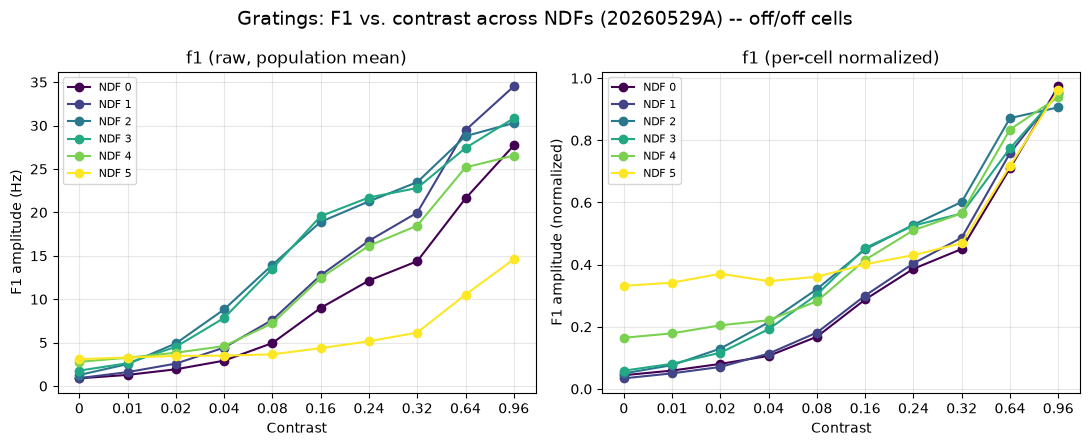

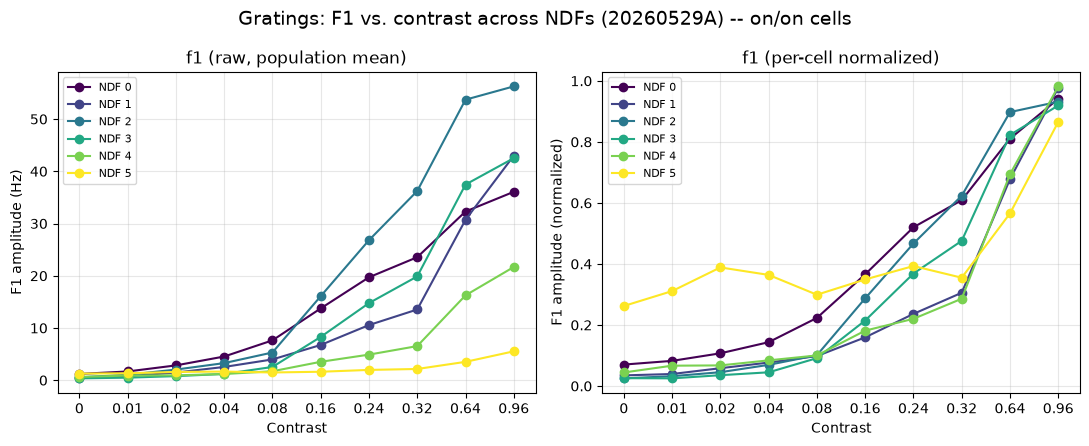

In [7]:
GRATING_PROTOCOL_NAME = 'manookinlab.protocols.ContrastResponseGrating'
CORR_THRESHOLD_GRATING = 0.85  # EI-matching cutoff (reference chunk <-> each NDF's datafile)
SHOW_SEM_ACROSS_NDFS = False  # quick on/off for the SEM error bars on these plots

figs_crf_all_ndfs_grating = plot_crf_across_ndfs(
    exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_key='contrast',
    analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
    response_col='f1', typing_chunk=typing_chunk,
    baseline_condition_key='contrast', baseline_condition_value=0.0,
    title_prefix=f'Gratings: F1 vs. contrast across NDFs ({exp_name})',
    show_sem=SHOW_SEM_ACROSS_NDFS, log_x=False, even_spacing=True,
)
# for cell_type, f in figs_crf_all_ndfs_grating.items():
#     f.savefig(f'{exp_name}_{cell_type}_crf_across_ndfs.png', dpi=300, bbox_inches='tight')  # uncomment to save


Same plot, true-to-scale log-x axis instead of the evenly-spaced linear one.

20260529A: found 6 NDF level(s) for 'manookinlab.protocols.ContrastResponseGrating': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


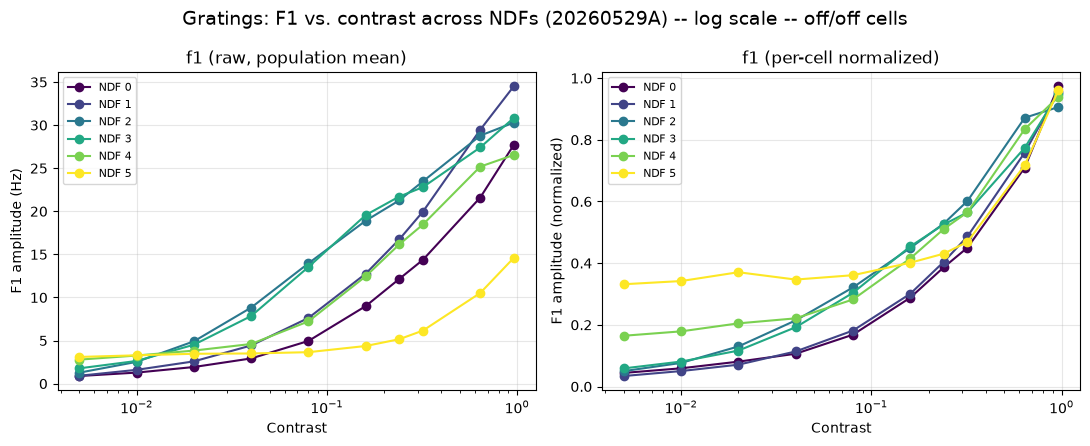

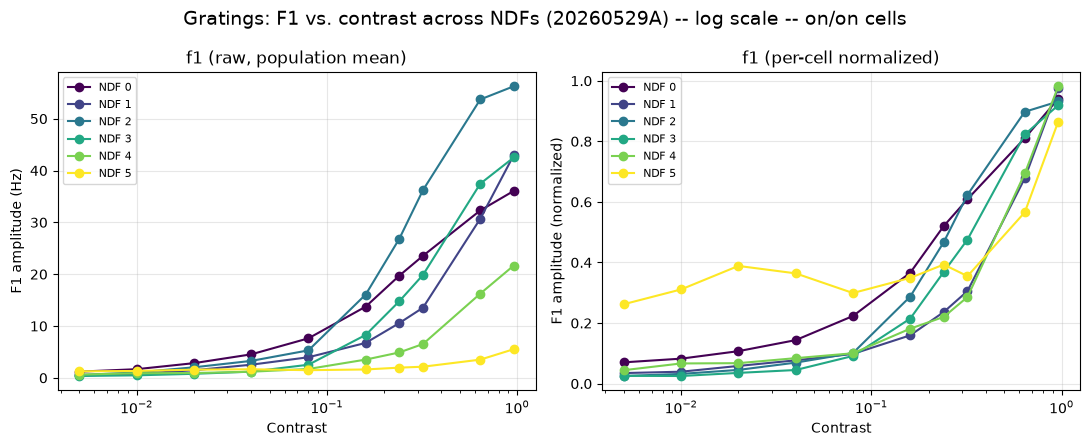

In [8]:
figs_crf_all_ndfs_grating_log = plot_crf_across_ndfs(
    exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_key='contrast',
    analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
    response_col='f1', typing_chunk=typing_chunk,
    baseline_condition_key='contrast', baseline_condition_value=0.0,
    title_prefix=f'Gratings: F1 vs. contrast across NDFs ({exp_name}) -- log scale',
    show_sem=SHOW_SEM_ACROSS_NDFS, log_x=True,
)
# for cell_type, f in figs_crf_all_ndfs_grating_log.items():
#     f.savefig(f'{exp_name}_{cell_type}_crf_across_ndfs_log.png', dpi=300, bbox_inches='tight')  # uncomment to save


---
# Section: export the plotted points

One row per (NDF, cell type, contrast): raw population mean/SEM and per-cell-normalized
mean/SEM, plus how many cells contributed. Same numbers as the two figures above --
`get_crf_points_across_ndfs` shares its loading and averaging code with
`plot_crf_across_ndfs`, so these can't disagree with what's plotted.

Set `CRF_POINTS_CSV_PATH = None` to skip saving to disk and just get the dataframe back.

In [ ]:
CRF_POINTS_CSV_PATH = f'{exp_name}_crf_points.csv'

df_crf_points_grating = get_crf_points_across_ndfs(
    exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_key='contrast',
    analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
    response_col='f1', typing_chunk=typing_chunk,
    baseline_condition_key='contrast', baseline_condition_value=0.0,
    save_csv_path=CRF_POINTS_CSV_PATH,
)
ra.scrollable_dataframe(df_crf_points_grating)


---
# Section: average across multiple experiments

Pools cells from every experiment in `EXP_NAMES_TO_AVERAGE` into one curve per NDF per cell
type, instead of `exp_name` alone. Each experiment's classified white-noise chunk is found
independently (same auto-detection as the setup cells above, per experiment) -- an
experiment missing a classified chunk, or missing `GRATING_PROTOCOL_NAME` at a given NDF, is
skipped for that part only and printed, the rest still contribute.

Set `MANUAL_ANALYSIS_CHUNKS`/`PREFERRED_TYPING_FILES` (dicts keyed by exp_name) to override
auto-detection for specific experiments, same idea as `MANUAL_ANALYSIS_CHUNK`/
`PREFERRED_TYPING_FILE` above but per experiment.

In [ ]:
EXP_NAMES_TO_AVERAGE = [exp_name]  # e.g. ['20260529A', '20260602A', '20260709A']
MANUAL_ANALYSIS_CHUNKS = None  # e.g. {'20260529A': 'data017'}
PREFERRED_TYPING_FILES = None  # e.g. {'20260529A': 'data017.classificationYT.txt'}
AVERAGED_CRF_CSV_PATH = 'averaged_crf_points.csv'  # set to None to skip saving

figs_crf_averaged, df_crf_points_averaged = plot_crf_across_experiments(
    EXP_NAMES_TO_AVERAGE, contrast_search, GRATING_PROTOCOL_NAME, condition_key='contrast',
    corr_cutoff=CORR_THRESHOLD_GRATING, response_col='f1',
    manual_analysis_chunks=MANUAL_ANALYSIS_CHUNKS, preferred_typing_files=PREFERRED_TYPING_FILES,
    baseline_condition_key='contrast', baseline_condition_value=0.0,
    title_prefix='Gratings: F1 vs. contrast across NDFs, averaged across experiments',
    show_sem=SHOW_SEM_ACROSS_NDFS, log_x=False, even_spacing=True,
    save_csv_path=AVERAGED_CRF_CSV_PATH,
)
ra.scrollable_dataframe(df_crf_points_averaged)
# for cell_type, f in figs_crf_averaged.items():
#     f.savefig(f'averaged_{cell_type}_crf_across_ndfs.png', dpi=300, bbox_inches='tight')  # uncomment to save
